In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import networkx as nx

In [ ]:
G = nx.read_edgelist("N40_y2.4.edgelist", nodetype=int)
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
N = A.shape[0]
k = A.sum(axis=1)
k_mean = k.mean()

In [ ]:
def social_network_ode(t, y, A, g, Gamma, kappa, gamma_p, sigma0, J, Delta, r):
    Nloc = A.shape[0]
    ReE, ImE = y[:Nloc], y[Nloc:2*Nloc]
    sigma, E = y[2*Nloc:3*Nloc], ReE + 1j*ImE
    alpha = (g**2) / (Gamma**2)
    coupling = (A * sigma0) @ E
    dE = -(kappa + 1j*Delta)*E + (g/Gamma)*sigma*E - 1j*alpha*J*sigma*coupling + r
    ds = gamma_p*(sigma0 - sigma) - 4*(g/Gamma)*sigma*np.abs(E)**2
    return np.concatenate([dE.real, dE.imag, ds])

def solve_social_fields(J, Delta, r, sigma0_vec, params):
    g, Gamma, kappa, gamma_p, sigma0 = params
    y0 = np.concatenate([E0.real, E0.imag, sigma0_vec])
    sol = solve_ivp(social_network_ode, (0, T), y0, t_eval=t_eval, method='BDF',
        args=(A, g, Gamma, kappa, gamma_p, sigma0, J, Delta, r),
        rtol=1e-6, atol=1e-9)
    E_t = sol.y[:N] + 1j*sol.y[N:2*N]
    sigma_t = sol.y[2*N:3*N]
    return sol.t, E_t, np.abs(E_t), np.abs(E_t)**2, sigma_t

def mean_social_curves(E_t, sigma_t, k):
    E2 = np.abs(E_t)**2
    N = E_t.shape[0]
    I_mean = E2.mean(axis=0)
    Z_mean = sigma_t.mean(axis=0)
    k_mean = np.mean(k)
    norm = 1 / (N * k_mean)
    I_mean_k = norm * np.sum(k[:, None] * E2, axis=0)
    Z_mean_k = norm * np.sum(k[:, None] * sigma_t, axis=0)
    return I_mean_k, Z_mean_k

In [ ]:
# Functions for finding thresholds
def perron_zeta(A):
    return float(np.linalg.eigvalsh(A).max()) if np.allclose(A, A.T) \
           else float(np.linalg.eigvals(A).real.max())

def thresholds_formula_compact(g, Gamma, kappa, J, zeta, eps=1e-20):
    sigma_loc = (kappa * Gamma) / g
    a = (g**2 / Gamma**2) * (J.imag) * zeta
    b = (g / Gamma)
    if abs(a) < eps:
        return {"sigma_loc": sigma_loc, "sigma_1": np.float64(sigma_loc), "sigma_2": np.float64(np.inf)}
    disc = b*b + 4*a*kappa
    if disc < 0:
        return {"sigma_loc": sigma_loc, "sigma_1": np.float64(np.nan), "sigma_2": np.float64(np.nan)}
    s = np.sqrt(disc)
    r1 = (-b - s) / (2*a)
    r2 = (-b + s) / (2*a)
    r1, r2 = sorted([r1, r2])
    return {"sigma_loc": sigma_loc, "sigma_1": np.float64(r1), "sigma_2": np.float64(r2)}

def all_thresholds_one_call(A, J, params):
    g, Gamma, kappa, gamma_p, sigma0 = params
    zeta = perron_zeta(A)
    form = thresholds_formula_compact(g, Gamma, kappa, J, zeta)
    print("sigma_loc =", form["sigma_loc"])
    print("sigma_1   =", form["sigma_1"])
    print("sigma_2   =", form["sigma_2"])
    thr_dyn = np.nan
    return form, thr_dyn

In [ ]:
# Thresholds
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, 0.48)
form, thr_dyn = all_thresholds_one_call(A=A, J=0.25j, params=params)

sigma_loc = 0.18749999999999997
sigma_1   = -0.8938557193347489
sigma_2   = 0.15498872792606283


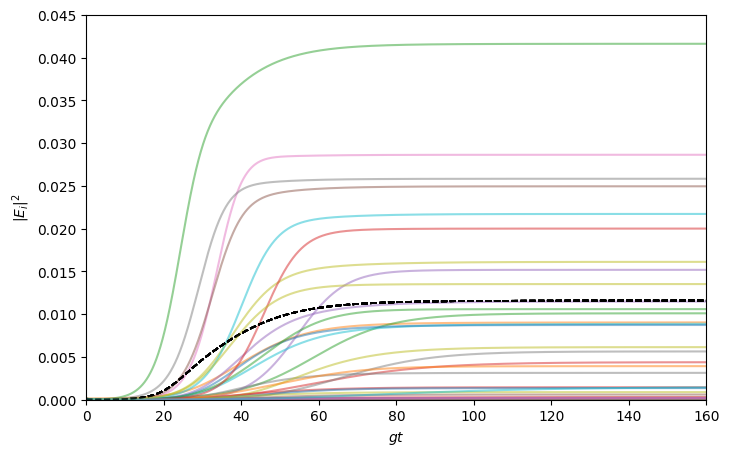

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.150, 0.05, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)  # g, Gamma, kappa, gamma_p, sigma0
T, Nt = 6000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 160)
plt.ylim(0, 0.045)
plt.show()

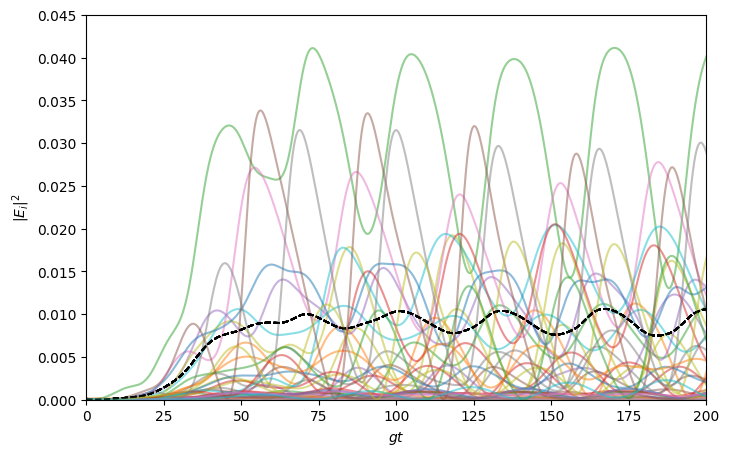

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.150, 0.05, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 6000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=1+0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 200)
plt.ylim(0, 0.045)
plt.show()

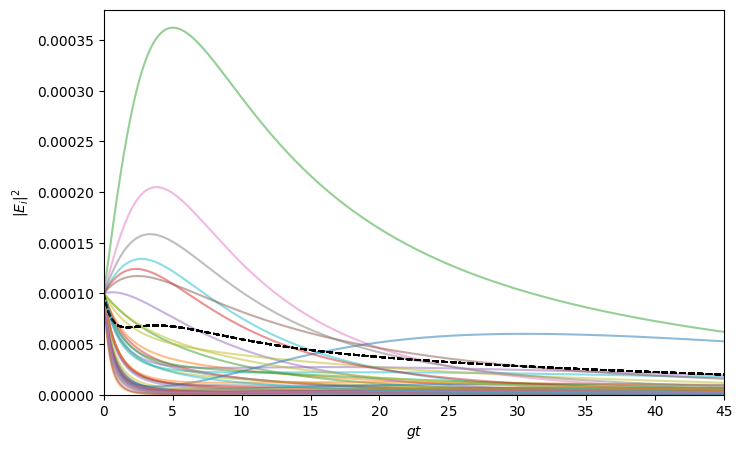

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0_d = 0.150
sigma0 = sigma0_d * (np.ones(N))
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 600, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 45)
plt.ylim(0, 0.00038)
plt.show()

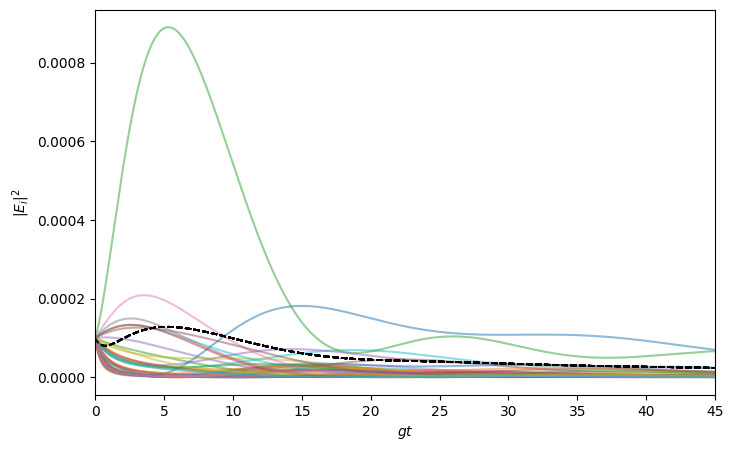

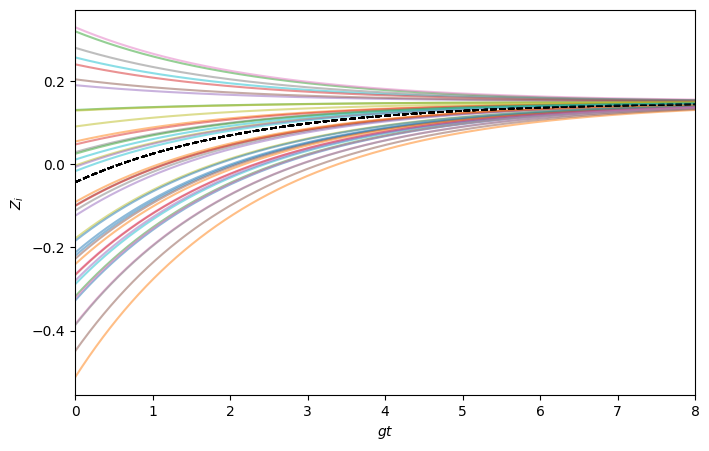

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0_d = 0.150
sigma0 = sigma0_d * (np.ones(N))

params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 600, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=1+0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 45)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=1+0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 8)
plt.show()

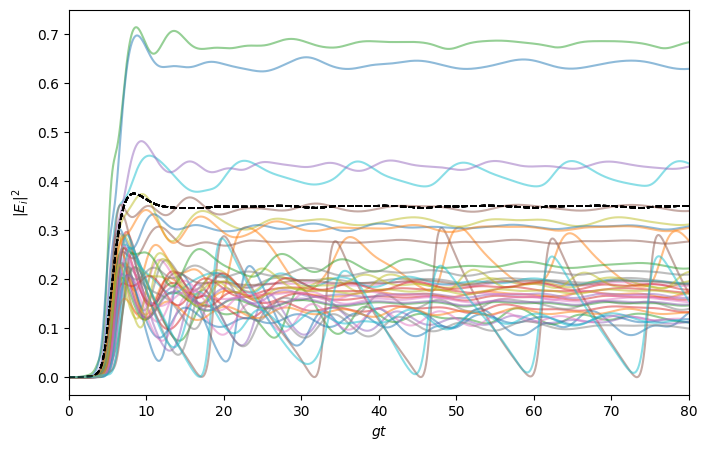

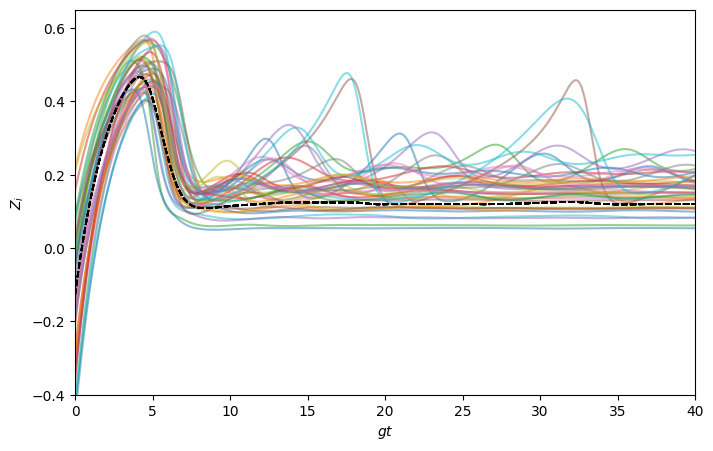

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(0.6, 0.05, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 500, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.1, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=1+0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 80)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=1+0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 40)
plt.ylim(-0.4, 0.65)
plt.show()

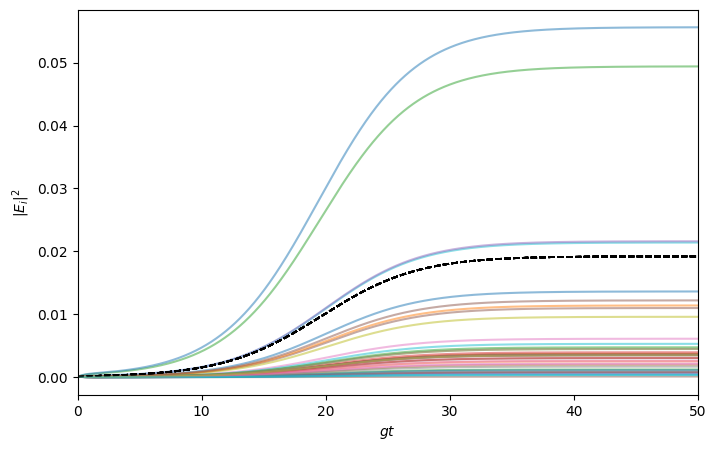

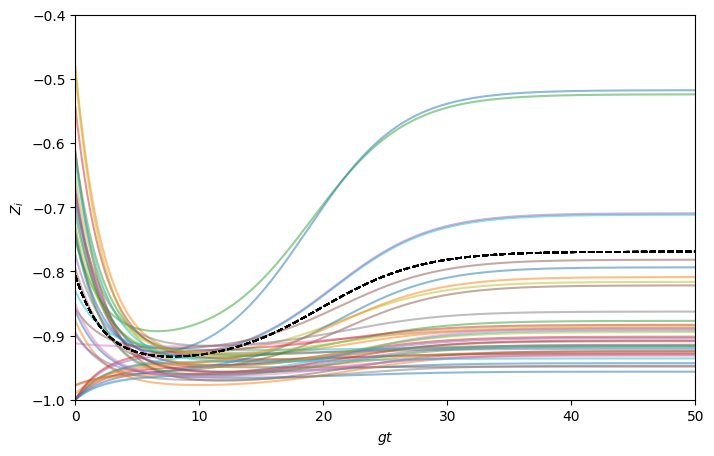

In [ ]:
SEED = 35
rng = np.random.default_rng(SEED)

sigma0 = np.clip(rng.normal(-0.95, 0.015, N), -1, 1)
params = (0.4, 0.6, 0.05/0.4, 0.07/0.4, sigma0)
T, Nt = 5000, 100000
t_eval = np.linspace(0, T, Nt)
E0 = 1e-2 * (np.ones(N))
sigma0_vec = np.clip(rng.normal(-0.8, 0.2, N), -1, 1)

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, E2_mod[i], alpha=0.5); plt.plot(params[0]*t, E2_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$|E_i|^2$'); plt.title('');
plt.xlim(0, 50)
plt.show()

plt.figure(figsize=(8,5))
t, E_t, E_mod, E2_mod, sigma_t = solve_social_fields(J=0.25j, Delta=0.0, r=0.0, sigma0_vec=sigma0_vec, params=params)
E2_mean_k, Z_mean_k = mean_social_curves(E_t, sigma_t, k)
for i in range(N): plt.plot(params[0]*t, sigma_t[i], alpha=0.5); plt.plot(params[0]*t, Z_mean_k, color='k', linestyle='--', linewidth=1.2, alpha=0.6)
plt.xlabel(r'$g t$'); plt.ylabel(r'$Z_i$'); plt.title('');
plt.xlim(0, 50)
plt.ylim(-1, -0.4)
plt.show()